In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    SpectralClustering
)

from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score
)

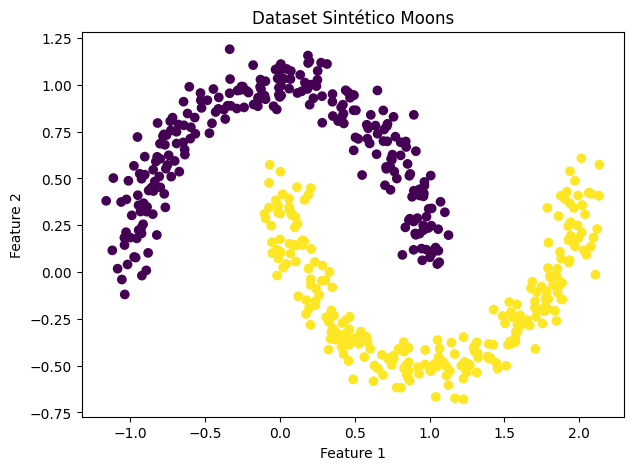

Cantidad de muestras: 500
Ruido: 0.08


In [ ]:
RANDOM_STATE = 42
N_SAMPLES = 500
NOISE = 0.08

X, y_true = make_moons(
    n_samples=N_SAMPLES,
    noise=NOISE,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(7,5))
plt.scatter(
    X[:,0],
    X[:,1],
    c=y_true,
    cmap="viridis"
)

plt.title("Dataset Sintético Moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Cantidad de muestras:", N_SAMPLES)
print("Ruido:", NOISE)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados correctamente")

Datos escalados correctamente


In [ ]:
print("HIPERPARÁMETROS")

print("\nK-Means")
print("n_clusters = 2")

print("\nDBSCAN")
print("eps = 0.30")
print("min_samples = 5")

print("\nSpectral Clustering")
print("n_clusters = 2")
print("affinity = rbf")
print("gamma = 1.0")

HIPERPARÁMETROS

K-Means
n_clusters = 2

DBSCAN
eps = 0.30
min_samples = 5

Spectral Clustering
n_clusters = 2
affinity = rbf
gamma = 1.0


In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=RANDOM_STATE,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X_scaled)


dbscan = DBSCAN(
    eps=0.30,
    min_samples=5
)

y_dbscan = dbscan.fit_predict(X_scaled)


spectral = SpectralClustering(
    n_clusters=2,
    affinity='rbf',
    gamma=1.0,
    random_state=RANDOM_STATE
)

y_spectral = spectral.fit_predict(X_scaled)

In [ ]:
def calcular_metricas(y_real, y_pred, X):

    ari = adjusted_rand_score(
        y_real,
        y_pred
    )

    v_measure = v_measure_score(
        y_real,
        y_pred
    )

    mask = y_pred != -1

    if len(np.unique(y_pred[mask])) >= 2:

        silhouette = silhouette_score(
            X[mask],
            y_pred[mask]
        )

        dbi = davies_bouldin_score(
            X[mask],
            y_pred[mask]
        )

    else:

        silhouette = np.nan
        dbi = np.nan

    return ari, v_measure, silhouette, dbi

In [ ]:
ari_k, v_k, sil_k, dbi_k = calcular_metricas(
    y_true,
    y_kmeans,
    X_scaled
)

ari_d, v_d, sil_d, dbi_d = calcular_metricas(
    y_true,
    y_dbscan,
    X_scaled
)

ari_s, v_s, sil_s, dbi_s = calcular_metricas(
    y_true,
    y_spectral,
    X_scaled
)

In [ ]:
resultados = pd.DataFrame({
    "Modelo":[
        "K-Means",
        "DBSCAN",
        "Spectral Clustering"
    ],
    "ARI":[
        ari_k,
        ari_d,
        ari_s
    ],
    "V-Measure":[
        v_k,
        v_d,
        v_s
    ],
    "Silhouette":[
        sil_k,
        sil_d,
        sil_s
    ],
    "Davies-Bouldin":[
        dbi_k,
        dbi_d,
        dbi_s
    ]
})

resultados

,Modelo,ARI,V-Measure,Silhouette,Davies-Bouldin
0,K-Means,0.445112,0.351539,0.493200,0.813242
1,DBSCAN,1.000000,1.000000,0.383553,1.024061
2,Spectral Clustering,0.517433,0.415999,0.491320,0.816034


In [ ]:
print(resultados.round(4))

                Modelo     ARI  V-Measure  Silhouette  Davies-Bouldin
0              K-Means  0.4451     0.3515      0.4932          0.8132
1               DBSCAN  1.0000     1.0000      0.3836          1.0241
2  Spectral Clustering  0.5174     0.4160      0.4913          0.8160


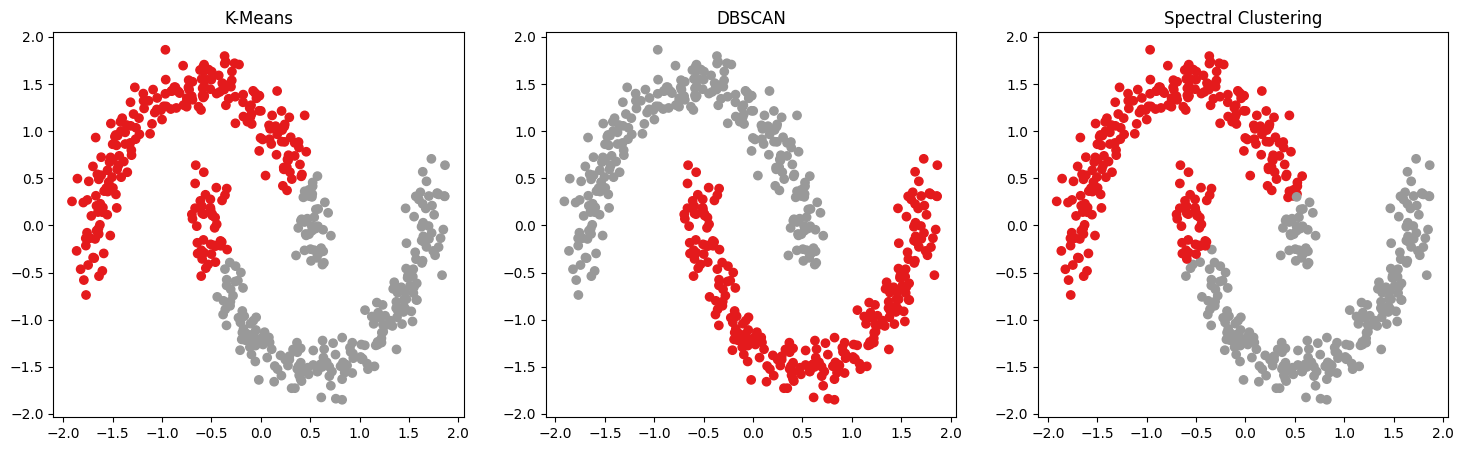

In [ ]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

ax[0].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y_kmeans,
    cmap="Set1"
)

ax[0].set_title("K-Means")


ax[1].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y_dbscan,
    cmap="Set1"
)

ax[1].set_title("DBSCAN")


ax[2].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y_spectral,
    cmap="Set1"
)

ax[2].set_title("Spectral Clustering")

plt.show()

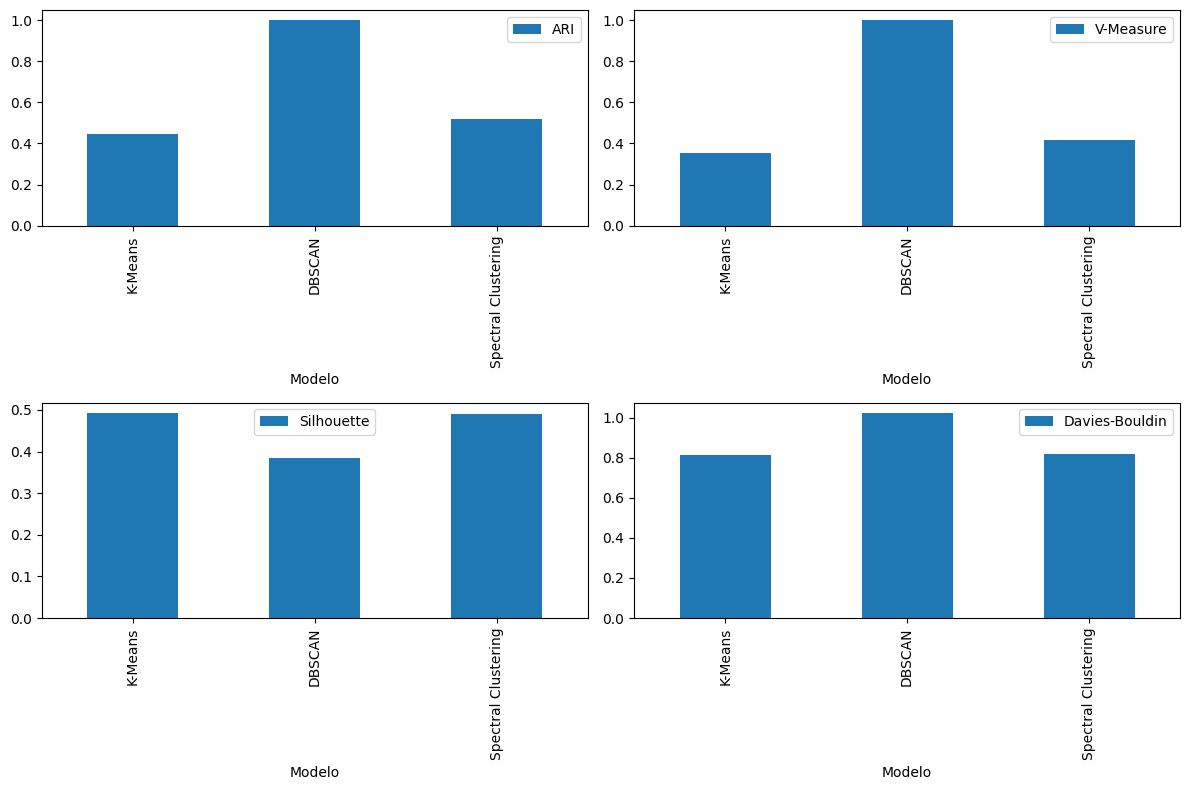

In [ ]:
fig, ax = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

resultados.plot(
    x="Modelo",
    y="ARI",
    kind="bar",
    ax=ax[0,0]
)

resultados.plot(
    x="Modelo",
    y="V-Measure",
    kind="bar",
    ax=ax[0,1]
)

resultados.plot(
    x="Modelo",
    y="Silhouette",
    kind="bar",
    ax=ax[1,0]
)

resultados.plot(
    x="Modelo",
    y="Davies-Bouldin",
    kind="bar",
    ax=ax[1,1]
)

plt.tight_layout()
plt.show()

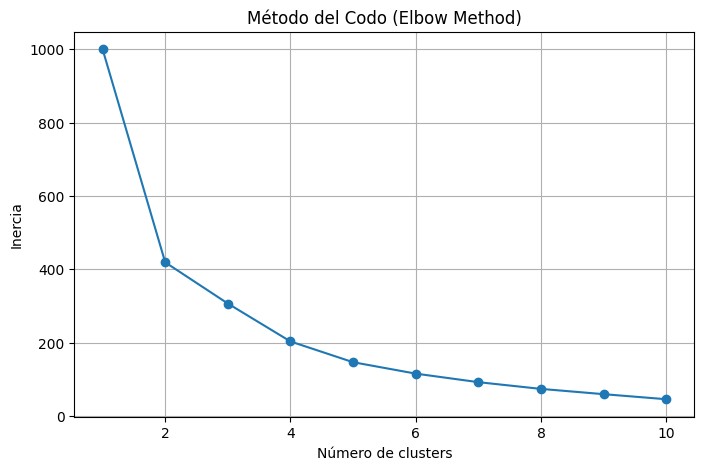

In [ ]:
inertias = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertias.append(
        km.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertias,
    marker="o"
)

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.title(
    "Método del Codo (Elbow Method)"
)

plt.grid(True)

plt.show()

In [ ]:
mejor_modelo = resultados.loc[
    resultados["ARI"].idxmax()
]

print("MEJOR MODELO")

print("\nModelo:", mejor_modelo["Modelo"])
print("ARI:", round(mejor_modelo["ARI"],4))
print("V-Measure:", round(mejor_modelo["V-Measure"],4))

MEJOR MODELO

Modelo: DBSCAN
ARI: 1.0
V-Measure: 1.0


In [ ]:
print("""
CONCLUSIONES

1. K-Means es un algoritmo lineal basado en centroides.

2. DBSCAN es un algoritmo no lineal basado en densidad.

3. Spectral Clustering es un algoritmo no lineal
   basado en grafos de similitud.

4. En el dataset Moons los modelos no lineales
   suelen obtener mejores resultados.

5. ARI y V-Measure evalúan qué tan cerca están
   los clusters de las clases reales.

6. Silhouette y Davies-Bouldin evalúan la calidad
   interna del agrupamiento.

7. El modelo con mejor ARI puede considerarse
   el más adecuado para este problema.
""")c


CONCLUSIONES

1. K-Means es un algoritmo lineal basado en centroides.

2. DBSCAN es un algoritmo no lineal basado en densidad.

3. Spectral Clustering es un algoritmo no lineal
   basado en grafos de similitud.

4. En el dataset Moons los modelos no lineales
   suelen obtener mejores resultados.

5. ARI y V-Measure evalúan qué tan cerca están
   los clusters de las clases reales.

6. Silhouette y Davies-Bouldin evalúan la calidad
   interna del agrupamiento.

7. El modelo con mejor ARI puede considerarse
   el más adecuado para este problema.

